In [1]:
# ==========================================
# USER SETTINGS
# ==========================================

FIRST_NAME = "Dylan"
LAST_NAME = "Cease"

SEASON = 2026

START_DATE = f"{SEASON}-03-01"
END_DATE = None

# False = update only missing/recent data
# True = rebuild data from Statcast
FORCE_REFRESH = False

# Number of recent days to re-check for Statcast corrections
REFRESH_OVERLAP_DAYS = 3

In [2]:
import os
import sqlite3
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pybaseball import (
    statcast_pitcher,
    playerid_lookup
)

In [3]:
DATA_DIR = "data"

os.makedirs(DATA_DIR, exist_ok=True)

DB_PATH = os.path.join(
    DATA_DIR,
    "pitching_statcast.sqlite"
)

print("Database:")
print(DB_PATH)

Database:
data\pitching_statcast.sqlite


In [4]:
# ==========================================
# PLAYER ID LOOKUP
# ==========================================

def lookup_statcast_id(first_name, last_name):

    lookup = playerid_lookup(
        last_name,
        first_name
    )

    if lookup.empty:
        raise ValueError(
            f"No player found for {first_name} {last_name}"
        )

    # Prefer most recent MLB record
    if "mlb_played_last" in lookup.columns:
        lookup = lookup.sort_values(
            "mlb_played_last",
            ascending=False
        )

    player_id = int(
        lookup.iloc[0]["key_mlbam"]
    )

    return player_id

In [5]:
PLAYER_ID = lookup_statcast_id(
    FIRST_NAME,
    LAST_NAME
)

print(
    f"{FIRST_NAME} {LAST_NAME} "
    f"Statcast ID: {PLAYER_ID}"
)

Gathering player lookup table. This may take a moment.
Dylan Cease Statcast ID: 656302


In [6]:
# ==========================================
# DATABASE INITIALIZATION
# ==========================================

def initialize_database():

    conn = sqlite3.connect(DB_PATH)

    conn.execute("""
        CREATE TABLE IF NOT EXISTS pitcher_data (
            pitcher_id INTEGER,
            game_pk INTEGER,
            game_date TEXT,
            at_bat_number INTEGER,
            pitch_number INTEGER,
            pitch_type TEXT,
            pitch_name TEXT,
            release_speed REAL,
            release_spin_rate REAL,
            pfx_x REAL,
            pfx_z REAL,
            plate_x REAL,
            plate_z REAL,
            balls INTEGER,
            strikes INTEGER,
            description TEXT,
            events TEXT,
            inning INTEGER,
            inning_topbot TEXT,
            batter INTEGER,
            stand TEXT,
            home_team TEXT,
            away_team TEXT,
            release_extension REAL,
            effective_speed REAL,
            estimated_woba_using_speedangle REAL
        )
    """)

    conn.commit()
    conn.close()


initialize_database()

print("Database initialized.")

Database initialized.


In [7]:
# ==========================================
# DATE HELPERS
# ==========================================

def get_end_date():

    if END_DATE is not None:
        return END_DATE

    return datetime.now().strftime("%Y-%m-%d")

In [8]:
def get_latest_database_date(player_id):

    conn = sqlite3.connect(DB_PATH)

    query = """
        SELECT MAX(game_date)
        FROM pitcher_data
        WHERE pitcher_id = ?
    """

    result = conn.execute(
        query,
        (player_id,)
    ).fetchone()[0]

    conn.close()

    return result

In [9]:
def download_statcast_data(
    player_id,
    start_date,
    end_date
):

    print(
        f"Downloading Statcast data:"
        f"\n{start_date} through {end_date}"
    )

    df = statcast_pitcher(
        start_date,
        end_date,
        player_id
    )

    if df.empty:
        print("No Statcast data returned.")
        return df

    df = df.copy()

    df["pitcher_id"] = player_id

    df["game_date"] = pd.to_datetime(
        df["game_date"]
    ).dt.strftime("%Y-%m-%d")

    return df

In [10]:
# ==========================================
# DATABASE UPDATE
# ==========================================

DATABASE_COLUMNS = [

    "pitcher_id",
    "game_pk",
    "game_date",
    "at_bat_number",
    "pitch_number",
    "pitch_type",
    "pitch_name",
    "release_speed",
    "release_spin_rate",
    "pfx_x",
    "pfx_z",
    "plate_x",
    "plate_z",
    "balls",
    "strikes",
    "description",
    "events",
    "inning",
    "inning_topbot",
    "batter",
    "stand",
    "home_team",
    "away_team",
    "release_extension",
    "effective_speed",
    "estimated_woba_using_speedangle"
]

In [11]:
def save_statcast_data(
    df,
    player_id,
    start_date,
    end_date
):

    if df.empty:
        return

    available_columns = [
        col for col in DATABASE_COLUMNS
        if col in df.columns
    ]

    save_df = df[
        available_columns
    ].copy()

    conn = sqlite3.connect(DB_PATH)

    # Remove overlapping records first
    conn.execute(
        """
        DELETE FROM pitcher_data
        WHERE pitcher_id = ?
        AND game_date BETWEEN ? AND ?
        """,
        (
            player_id,
            start_date,
            end_date
        )
    )

    save_df.to_sql(
        "pitcher_data",
        conn,
        if_exists="append",
        index=False
    )

    conn.commit()
    conn.close()

In [12]:
# ==========================================
# AUTO UPDATE
# ==========================================

def update_pitcher_database(
    player_id,
    season_start,
    force_refresh=False
):

    end_date = get_end_date()

    latest_date = get_latest_database_date(
        player_id
    )

    if force_refresh or latest_date is None:

        update_start = season_start

        print(
            "Performing full Statcast download."
        )

    else:

        latest_date = pd.to_datetime(
            latest_date
        )

        update_start = (
            latest_date
            - timedelta(
                days=REFRESH_OVERLAP_DAYS
            )
        ).strftime("%Y-%m-%d")

        print(
            f"Existing data found through "
            f"{latest_date.date()}."
        )

    df = download_statcast_data(
        player_id,
        update_start,
        end_date
    )

    save_statcast_data(
        df,
        player_id,
        update_start,
        end_date
    )

    print("Database update complete.")

In [13]:
update_pitcher_database(
    PLAYER_ID,
    START_DATE,
    FORCE_REFRESH
)

Performing full Statcast download.
2026-03-01 through 2026-09-18
Gathering Player Data
Database update complete.


In [14]:
# ==========================================
# LOAD PITCHER DATA
# ==========================================

def load_pitcher_data(
    player_id,
    season
):

    conn = sqlite3.connect(DB_PATH)

    query = """
        SELECT *
        FROM pitcher_data
        WHERE pitcher_id = ?
        AND game_date BETWEEN ? AND ?
        ORDER BY
            game_date,
            game_pk,
            at_bat_number,
            pitch_number
    """

    start = f"{season}-01-01"
    end = f"{season}-12-31"

    df = pd.read_sql_query(
        query,
        conn,
        params=(
            player_id,
            start,
            end
        )
    )

    conn.close()

    df["game_date"] = pd.to_datetime(
        df["game_date"]
    )

    return df

In [15]:
pitcher_df = load_pitcher_data(
    PLAYER_ID,
    SEASON
)

print(
    f"{len(pitcher_df):,} pitches loaded."
)

pitcher_df.head()

2,959 pitches loaded.


,pitcher_id,game_pk,game_date,at_bat_number,pitch_number,pitch_type,pitch_name,release_speed,release_spin_rate,pfx_x,...,events,inning,inning_topbot,batter,stand,home_team,away_team,release_extension,effective_speed,estimated_woba_using_speedangle
0,656302,831513,2026-03-10,1,1,FF,4-Seam Fastball,98.1,2464.0,-0.48,...,None,1,Top,663897,R,TOR,ATL,6.5,98.8,NaN
1,656302,831513,2026-03-10,1,2,SL,Slider,89.0,2701.0,0.07,...,None,1,Top,663897,R,TOR,ATL,6.4,89.7,NaN
2,656302,831513,2026-03-10,1,3,SI,Sinker,96.9,2353.0,-0.96,...,field_error,1,Top,663897,R,TOR,ATL,6.3,97.4,NaN
3,656302,831513,2026-03-10,2,1,FF,4-Seam Fastball,97.4,2555.0,-0.59,...,None,1,Top,592325,L,TOR,ATL,6.3,97.6,NaN
4,656302,831513,2026-03-10,2,2,FF,4-Seam Fastball,96.4,2523.0,-0.64,...,None,1,Top,592325,L,TOR,ATL,6.2,96.7,NaN


In [16]:
# ==========================================
# DATA SUMMARY
# ==========================================

print(
    f"Pitcher: {FIRST_NAME} {LAST_NAME}"
)

print(
    f"Season: {SEASON}"
)

print(
    f"Pitches: {len(pitcher_df):,}"
)

print(
    f"Games: {pitcher_df['game_pk'].nunique()}"
)

print(
    f"First game: "
    f"{pitcher_df['game_date'].min()}"
)

print(
    f"Latest game: "
    f"{pitcher_df['game_date'].max()}"
)

print("\nPitch Types:")

display(
    pitcher_df[
        ["pitch_type", "pitch_name"]
    ]
    .drop_duplicates()
    .sort_values("pitch_name")
)

Pitcher: Dylan Cease
Season: 2026
Pitches: 2,959
Games: 30
First game: 2026-03-10 00:00:00
Latest game: 2026-09-13 00:00:00

Pitch Types:


,pitch_type,pitch_name
0,FF,4-Seam Fastball
57,CH,Changeup
16,KC,Knuckle Curve
2,SI,Sinker
1,SL,Slider
9,ST,Sweeper
1186,None,None


In [17]:
# ==========================================
# ANALYSIS SETTINGS
# ==========================================

PITCH_TYPE = "FF"

In [18]:
# ==========================================
# SEASON VELOCITY BY GAME
# ==========================================

def game_velocity_summary(
    df,
    pitch_type
):

    pitch_df = df[
        df["pitch_type"] == pitch_type
    ].copy()

    summary = (
        pitch_df
        .groupby(
            ["game_pk", "game_date"]
        )
        .agg(
            avg_velocity=(
                "release_speed",
                "mean"
            ),
            max_velocity=(
                "release_speed",
                "max"
            ),
            pitches=(
                "release_speed",
                "count"
            )
        )
        .reset_index()
        .sort_values("game_date")
    )

    return summary

In [19]:
season_velocity = game_velocity_summary(
    pitcher_df,
    PITCH_TYPE
)

season_velocity.head()

,game_pk,game_date,avg_velocity,max_velocity,pitches
28,831513,2026-03-10,97.712500,99.2,16
29,831592,2026-03-22,97.330000,98.8,20
14,822838,2026-03-28,98.650000,100.0,24
23,824621,2026-04-03,97.812121,99.6,33
13,822833,2026-04-08,97.619444,99.4,36


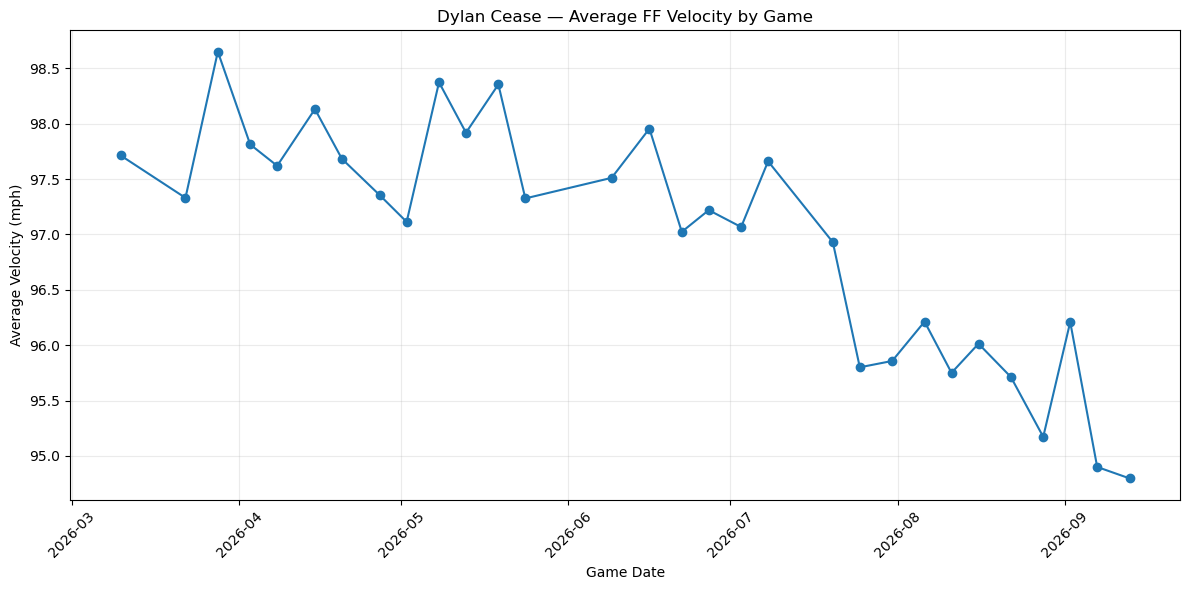

In [20]:
# ==========================================
# SEASON VELOCITY GRAPH
# ==========================================

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    season_velocity["game_date"],
    season_velocity["avg_velocity"],
    marker="o"
)

ax.set_title(
    f"{FIRST_NAME} {LAST_NAME} "
    f"— Average {PITCH_TYPE} Velocity by Game"
)

ax.set_xlabel("Game Date")
ax.set_ylabel("Average Velocity (mph)")

ax.grid(
    alpha=0.25
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

In [21]:
# ==========================================
# AVAILABLE GAMES
# ==========================================

games = (
    pitcher_df[
        [
            "game_pk",
            "game_date",
            "away_team",
            "home_team"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "game_date",
        ascending=False
    )
)

display(games)

,game_pk,game_date,away_team,home_team
2865,822764,2026-09-13,BAL,TOR
2771,824958,2026-09-07,TOR,ATH
2688,824390,2026-09-02,TOR,CLE
2596,822769,2026-08-28,SEA,TOR
2485,823509,2026-08-22,TOR,NYY
2381,822774,2026-08-16,NYY,TOR
2277,822778,2026-08-11,BOS,TOR
2173,824664,2026-08-06,TOR,CHC
2077,822782,2026-07-31,STL,TOR
1957,824734,2026-07-25,TOR,BOS


In [22]:
SELECTED_GAME_PK = int(
    games.iloc[0]["game_pk"]
)

In [23]:
# ==========================================
# INDIVIDUAL GAME ANALYSIS
# ==========================================

def game_pitch_data(
    df,
    game_pk,
    pitch_type=None,
    inning=None
):

    game_df = df[
        df["game_pk"] == game_pk
    ].copy()

    if pitch_type is not None:

        game_df = game_df[
            game_df["pitch_type"]
            == pitch_type
        ]

    if inning is not None:

        game_df = game_df[
            game_df["inning"]
            == inning
        ]

    game_df = game_df.sort_values(
        [
            "inning",
            "at_bat_number",
            "pitch_number"
        ]
    )

    game_df["selected_pitch_number"] = (
        range(
            1,
            len(game_df) + 1
        )
    )

    return game_df

In [24]:
game_df = game_pitch_data(
    pitcher_df,
    SELECTED_GAME_PK,
    PITCH_TYPE
)

display(
    game_df[
        [
            "selected_pitch_number",
            "inning",
            "balls",
            "strikes",
            "release_speed",
            "release_spin_rate",
            "description"
        ]
    ]
)

,selected_pitch_number,inning,balls,strikes,release_speed,release_spin_rate,description
2865,1,1,0,0,92.9,2272.0,foul
2868,2,1,2,1,93.5,2357.0,foul
2870,3,1,3,2,93.4,2327.0,foul
2878,4,1,1,0,93.5,2547.0,ball
2881,5,1,3,1,94.6,2514.0,foul
2882,6,1,3,2,95.3,2382.0,ball
2886,7,1,3,0,94.9,2380.0,called_strike
2889,8,1,3,2,95.7,2457.0,foul
2890,9,1,3,2,95.0,2467.0,called_strike
2894,10,1,0,0,94.6,2429.0,called_strike


In [26]:
SELECTED_GAME_PK = int(
    games.iloc[0]["game_pk"]
)

In [27]:
# ==========================================
# INDIVIDUAL GAME ANALYSIS
# ==========================================

def game_pitch_data(
    df,
    game_pk,
    pitch_type=None,
    inning=None
):

    game_df = df[
        df["game_pk"] == game_pk
    ].copy()

    if pitch_type is not None:

        game_df = game_df[
            game_df["pitch_type"]
            == pitch_type
        ]

    if inning is not None:

        game_df = game_df[
            game_df["inning"]
            == inning
        ]

    game_df = game_df.sort_values(
        [
            "inning",
            "at_bat_number",
            "pitch_number"
        ]
    )

    game_df["selected_pitch_number"] = (
        range(
            1,
            len(game_df) + 1
        )
    )

    return game_df

In [28]:
game_df = game_pitch_data(
    pitcher_df,
    SELECTED_GAME_PK,
    PITCH_TYPE
)

display(
    game_df[
        [
            "selected_pitch_number",
            "inning",
            "balls",
            "strikes",
            "release_speed",
            "release_spin_rate",
            "description"
        ]
    ]
)

,selected_pitch_number,inning,balls,strikes,release_speed,release_spin_rate,description
2865,1,1,0,0,92.9,2272.0,foul
2868,2,1,2,1,93.5,2357.0,foul
2870,3,1,3,2,93.4,2327.0,foul
2878,4,1,1,0,93.5,2547.0,ball
2881,5,1,3,1,94.6,2514.0,foul
2882,6,1,3,2,95.3,2382.0,ball
2886,7,1,3,0,94.9,2380.0,called_strike
2889,8,1,3,2,95.7,2457.0,foul
2890,9,1,3,2,95.0,2467.0,called_strike
2894,10,1,0,0,94.6,2429.0,called_strike


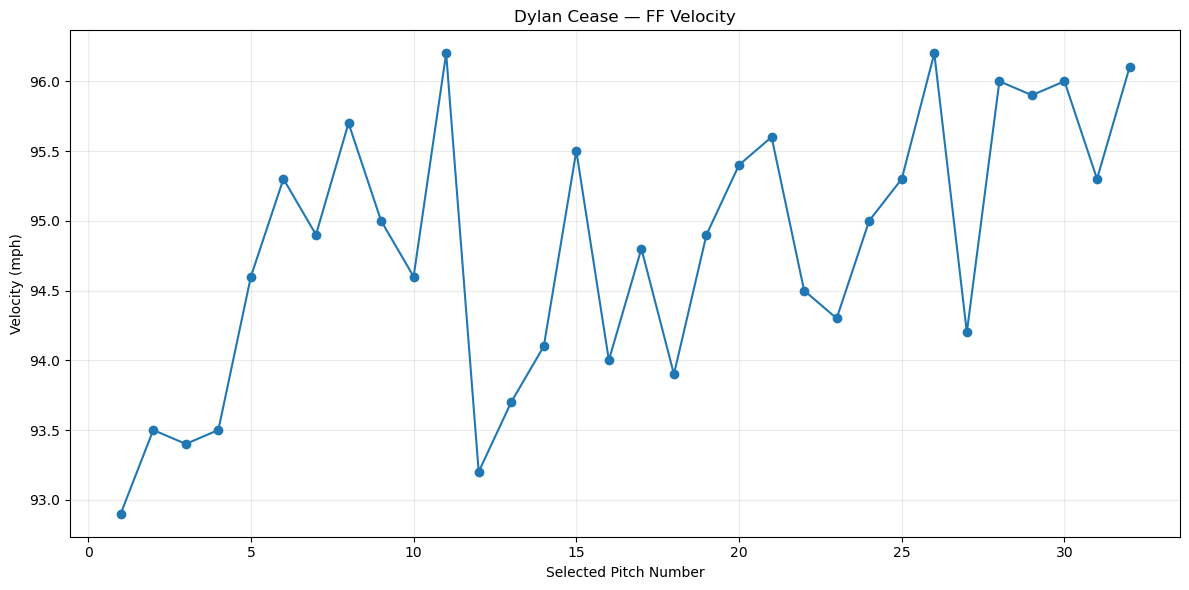

In [29]:
# ==========================================
# GAME PITCH-BY-PITCH VELOCITY
# ==========================================

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    game_df[
        "selected_pitch_number"
    ],
    game_df[
        "release_speed"
    ],
    marker="o"
)

ax.set_title(
    f"{FIRST_NAME} {LAST_NAME} "
    f"— {PITCH_TYPE} Velocity"
)

ax.set_xlabel(
    "Selected Pitch Number"
)

ax.set_ylabel(
    "Velocity (mph)"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [32]:
print(f"Selected game_pk: {SELECTED_GAME_PK}")
print(f"Selected pitch type: {PITCH_TYPE}")
print(f"Selected inning: {SELECTED_INNING}")
print(f"Pitches found: {len(inning_df)}")

display(inning_df[
    [
        "game_date",
        "inning",
        "pitch_type",
        "pitch_name",
        "release_speed",
        "description"
    ]
])

Selected game_pk: 822764
Selected pitch type: FF
Selected inning: 6
Pitches found: 0


,game_date,inning,pitch_type,pitch_name,release_speed,description


In [30]:
# ==========================================
# INNING ANALYSIS
# ==========================================

SELECTED_INNING = 6

inning_df = game_pitch_data(
    pitcher_df,
    SELECTED_GAME_PK,
    PITCH_TYPE,
    inning=SELECTED_INNING
)

display(
    inning_df[
        [
            "selected_pitch_number",
            "inning",
            "balls",
            "strikes",
            "release_speed",
            "release_spin_rate",
            "description"
        ]
    ]
)

,selected_pitch_number,inning,balls,strikes,release_speed,release_spin_rate,description


In [33]:
# ==========================================
# INNING PITCH-BY-PITCH VELOCITY
# ==========================================

if inning_df.empty:

    print(
        f"No {PITCH_TYPE} pitches found "
        f"in inning {SELECTED_INNING} "
        f"for the selected game."
    )

else:

    inning_df = inning_df.copy()

    inning_df["inning_pitch_number"] = range(
        1,
        len(inning_df) + 1
    )

    fig, ax = plt.subplots(
        figsize=(10, 5)
    )

    ax.plot(
        inning_df["inning_pitch_number"],
        inning_df["release_speed"],
        marker="o"
    )

    ax.set_title(
        f"{FIRST_NAME} {LAST_NAME} — "
        f"{PITCH_TYPE} Velocity — "
        f"Inning {SELECTED_INNING}"
    )

    ax.set_xlabel(
        f"{PITCH_TYPE} Pitch Number in Inning"
    )

    ax.set_ylabel(
        "Velocity (mph)"
    )

    ax.set_xticks(
        inning_df["inning_pitch_number"]
    )

    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

No FF pitches found in inning 6 for the selected game.


In [34]:
# ==========================================
# CURRENT / MOST RECENT GAME
# ==========================================

def get_latest_game(df):

    if df.empty:
        return pd.DataFrame()

    latest_date = df["game_date"].max()

    latest_games = df[
        df["game_date"] == latest_date
    ]

    latest_game_pk = latest_games[
        "game_pk"
    ].iloc[0]

    game_df = df[
        df["game_pk"] == latest_game_pk
    ].copy()

    return game_df


current_game_df = get_latest_game(
    pitcher_df
)

if current_game_df.empty:

    print("No game data available.")

else:

    print(
        f"Game: "
        f"{current_game_df['away_team'].iloc[0]} @ "
        f"{current_game_df['home_team'].iloc[0]}"
    )

    print(
        f"Date: "
        f"{current_game_df['game_date'].iloc[0]}"
    )

    print(
        f"Pitches recorded: "
        f"{len(current_game_df)}"
    )

Game: BAL @ TOR
Date: 2026-09-13 00:00:00
Pitches recorded: 94


In [35]:
# ==========================================
# CURRENT GAME PITCH SEQUENCE
# ==========================================

LIVE_PITCH_TYPE = "FF"

def create_pitch_sequence(
    game_df,
    pitch_type
):

    df = game_df[
        game_df["pitch_type"] == pitch_type
    ].copy()

    df = df.sort_values(
        [
            "inning",
            "at_bat_number",
            "pitch_number"
        ]
    )

    df = df.reset_index(drop=True)

    df["pitch_sequence"] = (
        np.arange(len(df)) + 1
    )

    return df


live_pitch_df = create_pitch_sequence(
    current_game_df,
    LIVE_PITCH_TYPE
)

print(
    f"{len(live_pitch_df)} "
    f"{LIVE_PITCH_TYPE} pitches found."
)

display(
    live_pitch_df[
        [
            "pitch_sequence",
            "inning",
            "balls",
            "strikes",
            "release_speed",
            "release_spin_rate",
            "description"
        ]
    ]
)

32 FF pitches found.


,pitch_sequence,inning,balls,strikes,release_speed,release_spin_rate,description
0,1,1,0,0,92.9,2272.0,foul
1,2,1,2,1,93.5,2357.0,foul
2,3,1,3,2,93.4,2327.0,foul
3,4,1,1,0,93.5,2547.0,ball
4,5,1,3,1,94.6,2514.0,foul
5,6,1,3,2,95.3,2382.0,ball
6,7,1,3,0,94.9,2380.0,called_strike
7,8,1,3,2,95.7,2457.0,foul
8,9,1,3,2,95.0,2467.0,called_strike
9,10,1,0,0,94.6,2429.0,called_strike


In [36]:
# ==========================================
# ROLLING VELOCITY
# ==========================================

ROLLING_WINDOW = 5

live_pitch_df[
    "rolling_velocity"
] = (
    live_pitch_df[
        "release_speed"
    ]
    .rolling(
        window=ROLLING_WINDOW,
        min_periods=1
    )
    .mean()
)

display(
    live_pitch_df[
        [
            "pitch_sequence",
            "inning",
            "release_speed",
            "rolling_velocity"
        ]
    ]
)

,pitch_sequence,inning,release_speed,rolling_velocity
0,1,1,92.9,92.900000
1,2,1,93.5,93.200000
2,3,1,93.4,93.266667
3,4,1,93.5,93.325000
4,5,1,94.6,93.580000
5,6,1,95.3,94.060000
6,7,1,94.9,94.340000
7,8,1,95.7,94.800000
8,9,1,95.0,95.100000
9,10,1,94.6,95.100000


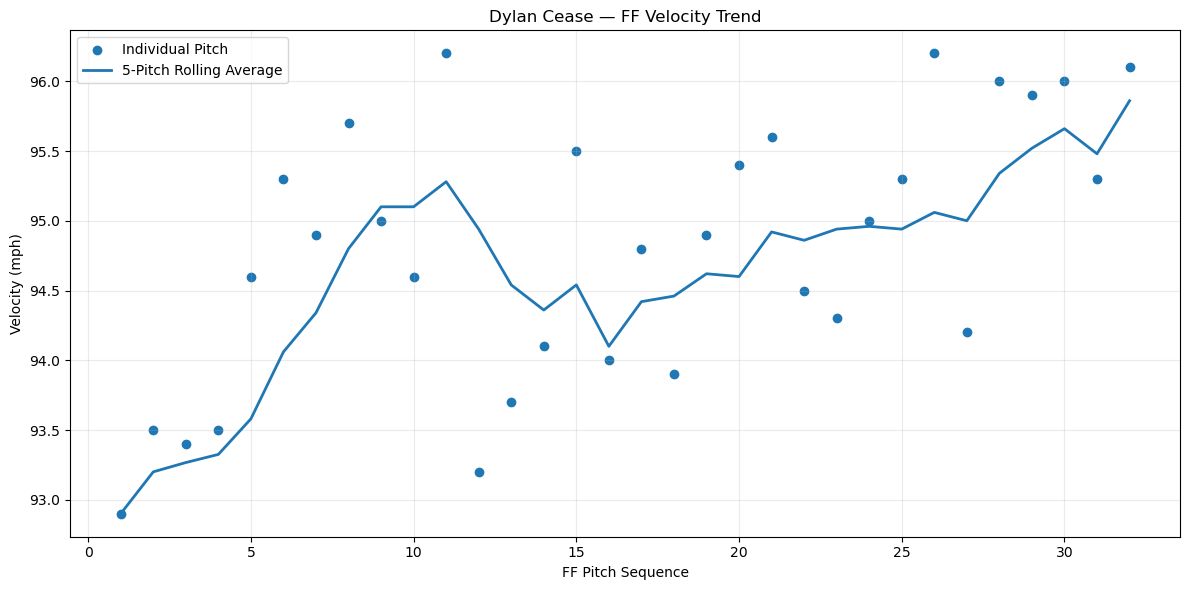

In [37]:
# ==========================================
# CURRENT GAME VELOCITY TREND
# ==========================================

if live_pitch_df.empty:

    print(
        f"No {LIVE_PITCH_TYPE} pitches "
        f"found in this game."
    )

else:

    fig, ax = plt.subplots(
        figsize=(12, 6)
    )

    ax.scatter(
        live_pitch_df["pitch_sequence"],
        live_pitch_df["release_speed"],
        label="Individual Pitch"
    )

    ax.plot(
        live_pitch_df["pitch_sequence"],
        live_pitch_df["rolling_velocity"],
        linewidth=2,
        label=f"{ROLLING_WINDOW}-Pitch Rolling Average"
    )

    ax.set_title(
        f"{FIRST_NAME} {LAST_NAME} — "
        f"{LIVE_PITCH_TYPE} Velocity Trend"
    )

    ax.set_xlabel(
        f"{LIVE_PITCH_TYPE} Pitch Sequence"
    )

    ax.set_ylabel(
        "Velocity (mph)"
    )

    ax.legend()

    ax.grid(
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

In [38]:
# ==========================================
# VELOCITY BY INNING
# ==========================================

def inning_velocity_summary(df):

    summary = (
        df
        .groupby("inning")
        .agg(
            avg_velocity=(
                "release_speed",
                "mean"
            ),
            max_velocity=(
                "release_speed",
                "max"
            ),
            min_velocity=(
                "release_speed",
                "min"
            ),
            pitch_count=(
                "release_speed",
                "count"
            )
        )
        .reset_index()
    )

    return summary


inning_summary = inning_velocity_summary(
    live_pitch_df
)

display(
    inning_summary.round(2)
)

,inning,avg_velocity,max_velocity,min_velocity,pitch_count
0,1,94.51,96.2,92.9,11
1,2,93.67,94.1,93.2,3
2,3,94.87,95.6,93.9,7
3,4,94.60,95.0,94.3,3
4,5,95.62,96.2,94.2,8


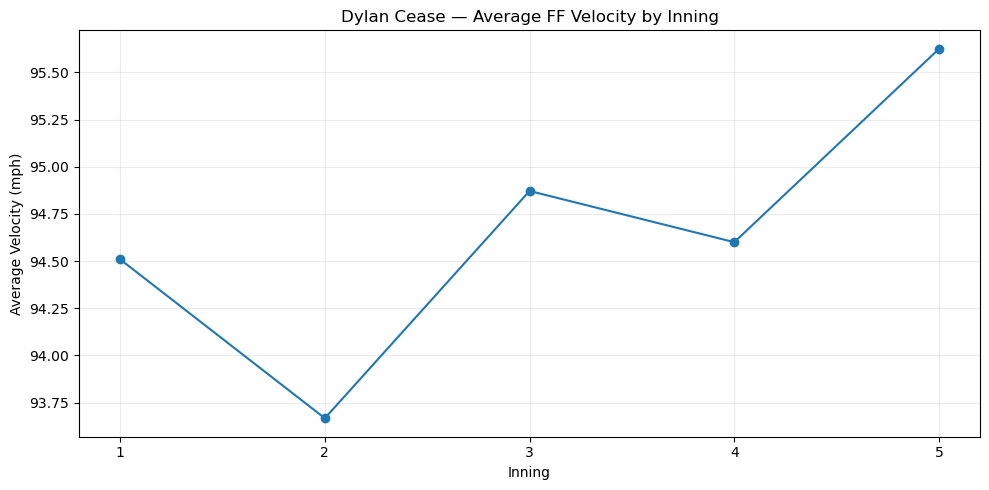

In [39]:
# ==========================================
# AVERAGE VELOCITY BY INNING
# ==========================================

if inning_summary.empty:

    print("No inning data available.")

else:

    fig, ax = plt.subplots(
        figsize=(10, 5)
    )

    ax.plot(
        inning_summary["inning"],
        inning_summary["avg_velocity"],
        marker="o"
    )

    ax.set_title(
        f"{FIRST_NAME} {LAST_NAME} — "
        f"Average {LIVE_PITCH_TYPE} Velocity by Inning"
    )

    ax.set_xlabel(
        "Inning"
    )

    ax.set_ylabel(
        "Average Velocity (mph)"
    )

    ax.set_xticks(
        inning_summary["inning"]
    )

    ax.grid(
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

In [40]:
# ==========================================
# GAME SUMMARY METRICS
# ==========================================

def calculate_game_metrics(df):

    if df.empty:

        return None

    velocities = (
        df["release_speed"]
        .dropna()
    )

    if velocities.empty:

        return None

    first_n = velocities.head(10)
    last_n = velocities.tail(10)

    metrics = {

        "pitch_count":
            len(velocities),

        "average_velocity":
            velocities.mean(),

        "max_velocity":
            velocities.max(),

        "latest_velocity":
            velocities.iloc[-1],

        "first_10_average":
            first_n.mean(),

        "last_10_average":
            last_n.mean(),

        "velocity_change":
            last_n.mean()
            - first_n.mean()
    }

    return metrics

In [41]:
game_metrics = calculate_game_metrics(
    live_pitch_df
)

if game_metrics:

    print(
        f"{FIRST_NAME} {LAST_NAME}"
    )

    print(
        f"{LIVE_PITCH_TYPE} — Current Game"
    )

    print(
        f"\nPitches: "
        f"{game_metrics['pitch_count']}"
    )

    print(
        f"Average: "
        f"{game_metrics['average_velocity']:.1f} mph"
    )

    print(
        f"Maximum: "
        f"{game_metrics['max_velocity']:.1f} mph"
    )

    print(
        f"Latest: "
        f"{game_metrics['latest_velocity']:.1f} mph"
    )

    print(
        f"First 10 Avg: "
        f"{game_metrics['first_10_average']:.1f} mph"
    )

    print(
        f"Last 10 Avg: "
        f"{game_metrics['last_10_average']:.1f} mph"
    )

    print(
        f"Change: "
        f"{game_metrics['velocity_change']:+.1f} mph"
    )

Dylan Cease
FF — Current Game

Pitches: 32
Average: 94.8 mph
Maximum: 96.2 mph
Latest: 96.1 mph
First 10 Avg: 94.3 mph
Last 10 Avg: 95.4 mph
Change: +1.1 mph


In [42]:
# ==========================================
# REFRESH DATA
# ==========================================

def refresh_pitcher_data():

    print(
        f"Checking for new Statcast data "
        f"for {FIRST_NAME} {LAST_NAME}..."
    )

    update_pitcher_database(
        PLAYER_ID,
        START_DATE,
        False
    )

    updated_df = load_pitcher_data(
        PLAYER_ID,
        SEASON
    )

    print(
        f"Database now contains "
        f"{len(updated_df):,} pitches."
    )

    print(
        f"Latest data: "
        f"{updated_df['game_date'].max()}"
    )

    return updated_df

In [43]:
pitcher_df = refresh_pitcher_data()

Checking for new Statcast data for Dylan Cease...
Existing data found through 2026-09-13.
2026-09-10 through 2026-09-18
Gathering Player Data
Database update complete.
Database now contains 2,959 pitches.
Latest data: 2026-09-13 00:00:00


In [46]:
import sys
print(sys.executable)

c:\Users\pauls\anaconda3\envs\dev\python.exe
